In [21]:
#!pip install numpy pillow
#!pip install pandas

## Exercise 1

In [22]:
import numpy as np 
from PIL import Image
import pandas as pd
import os

image_paths = [os.path.join("images",f) for f in os.listdir("images") if f.endswith(".png")]
data_list = []

for path in image_paths:
    img = Image.open(path).convert("L")
    data_list.append(np.array(img, dtype=float))

X = np.array(data_list)
print(X.shape)


(8, 32, 32)


In [23]:
X = X.reshape(X.shape[0], -1)
print(X.shape)

(8, 1024)


Given a matrix $X \in \mathbb{R}^{8 \times 1024}$:

- **Each row** represents a single image in the dataset, containing all pixel values after the image has been flattened into a one-dimensional vector.
- **Each column** represents a specific pixel location (fixed coordinate) shared across all 8 images.

In [24]:
mean_vector = np.mean(X, axis=0)
print(mean_vector.shape)

X_centered = X - mean_vector
print(X.shape)
print(X_centered.shape)
print(X_centered)

(1024,)
(8, 1024)
(8, 1024)
[[-66.75  -68.25  -65.875 ...  82.625  24.875  -2.875]
 [ 43.25   20.75  -10.875 ...  30.625  38.875  35.125]
 [127.25  139.75  139.125 ... -23.375 -16.125 -17.875]
 ...
 [ -8.75   -4.25   -0.875 ... -27.375 -15.125 -11.875]
 [ 52.25    7.75   20.125 ...   3.625   8.875  39.125]
 [-94.75  -79.25  -72.875 ...  21.625  26.875  21.125]]


NumPy broadcasting allows arithmetic operations between arrays of different shapes by automatically expanding the smaller array to match the larger one. In the operation `X - mean_vector`, where `X` has shape `(8, 1024)` and `mean_vector` has shape `(1024,)`, NumPy implicitly replicates the vector across all 8 rows and performs element-wise subtraction, producing an output matrix with the same shape as `X` (`8 × 1024`).

In [25]:
def cosine_similarity(X, Y=None):
    if Y is None:
        Y = X
    Xn = X/np.linalg.norm(X, axis=1, keepdims=True)
    Yn = Y/np.linalg.norm(Y, axis=1, keepdims=True)
    return Xn @ Yn.T
def search(query, X, top_k=3):
    similarities = cosine_similarity(query.reshape(1,-1),X)
    top_k_indices = np.argsort(similarities[0])[::-1][:top_k]
    top_scores = similarities[0][top_k_indices]
    return top_k_indices, top_scores

In [26]:
similarity_matrix = cosine_similarity(X_centered)
print(similarity_matrix.shape)

(8, 8)


In [27]:
df = pd.DataFrame(similarity_matrix, 
                  columns=[f"Image {i}" for i in range(8)], 
                  index=[f"Image {i}" for i in range(8)])
print(df)

          Image 0   Image 1   Image 2   Image 3   Image 4   Image 5   Image 6  \
Image 0  1.000000 -0.035257 -0.508686  0.435165 -0.199475 -0.067964 -0.136481   
Image 1 -0.035257  1.000000 -0.239901 -0.157600 -0.142755 -0.309153  0.066838   
Image 2 -0.508686 -0.239901  1.000000 -0.497767 -0.017934 -0.039039  0.076452   
Image 3  0.435165 -0.157600 -0.497767  1.000000  0.095703  0.189534 -0.419209   
Image 4 -0.199475 -0.142755 -0.017934  0.095703  1.000000 -0.124284 -0.457605   
Image 5 -0.067964 -0.309153 -0.039039  0.189534 -0.124284  1.000000 -0.190450   
Image 6 -0.136481  0.066838  0.076452 -0.419209 -0.457605 -0.190450  1.000000   
Image 7 -0.044483 -0.137726 -0.344258 -0.185274 -0.144604 -0.250458  0.016146   

          Image 7  
Image 0 -0.044483  
Image 1 -0.137726  
Image 2 -0.344258  
Image 3 -0.185274  
Image 4 -0.144604  
Image 5 -0.250458  
Image 6  0.016146  
Image 7  1.000000  


In [28]:
for i in range(8):
    query_img = X_centered[i]
    top_k_indices, top_k_scores = search(query_img, X_centered, top_k=3)

    print(f"\nQuery image: {i}")
    print(f"Most similar images: {top_k_indices}")
    print(f"Similarity scores: {top_k_scores}")


Query image: 0
Most similar images: [0 3 1]
Similarity scores: [ 1.          0.43516485 -0.03525697]

Query image: 1
Most similar images: [1 6 0]
Similarity scores: [ 1.          0.06683792 -0.03525697]

Query image: 2
Most similar images: [2 6 4]
Similarity scores: [ 1.          0.07645166 -0.01793352]

Query image: 3
Most similar images: [3 0 5]
Similarity scores: [1.         0.43516485 0.18953411]

Query image: 4
Most similar images: [4 3 2]
Similarity scores: [ 1.          0.09570301 -0.01793352]

Query image: 5
Most similar images: [5 3 2]
Similarity scores: [ 1.          0.18953411 -0.03903855]

Query image: 6
Most similar images: [6 2 1]
Similarity scores: [1.         0.07645166 0.06683792]

Query image: 7
Most similar images: [7 6 0]
Similarity scores: [ 1.          0.01614587 -0.04448314]


### Image Labels

| Index | Label |
|---------|---------|
| 0 | frog |
| 1 | truck |
| 2 | truck |
| 3 | deer |
| 4 | automobile |
| 5 | automobile |
| 6 | bird |
| 7 | horse |


### Discussion

The most similar pair is **Image 0 (frog)** and **Image 3 (deer)** with a cosine similarity score of **0.4352**. Although they belong to different classes, both images may share similar visual characteristics such as natural backgrounds, textures, or color distributions, resulting in a relatively high similarity score.

The most dissimilar pair is **Image 0 (frog)** and **Image 2 (truck)** with a score of **−0.5087**. This aligns well with intuition, as an animal image and a vehicle image typically exhibit very different visual patterns and structures.

Although **Image 1** and **Image 2** both belong to the *truck* class, their cosine similarity is **−0.2399**. This can be attributed to differences in viewing angle, object position, background, lighting conditions, and color distribution. Since cosine similarity is computed directly on flattened pixel vectors, even images of the same object category can appear dissimilar when their pixel arrangements differ significantly.

A similar observation applies to **Image 4** and **Image 5**, which both belong to the *automobile* class but have a cosine similarity of **−0.1243**. Variations in pose, scene context, and appearance can substantially alter pixel-level representations, leading to low or even negative similarity scores despite sharing the same semantic label.

## Exercise 2

In [29]:
#!pip install matplotlib
#!pip install opencv-python

### 1. Linear Transformations

In [30]:
import matplotlib.pyplot as plt
import cv2

In [31]:
H, W = 32, 32 
image = X[0].reshape(H, W)

theta = np.radians(45)
scale = 1.2

X_transform = np.array([
    [np.cos(theta) * scale, -np.sin(theta) * scale, 0],
    [np.sin(theta) * scale,  np.cos(theta) * scale, 0]
], dtype=np.float32)

image_transformed = cv2.warpAffine(image, X_transform, (W, H))

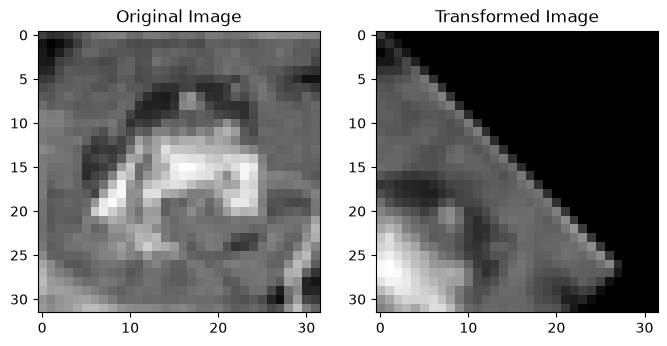

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(image, cmap='gray')
axes[0].set_title("Original Image")

axes[1].imshow(image_transformed, cmap='gray')
axes[1].set_title("Transformed Image")

plt.show()

### 2. Image Compression with SVD

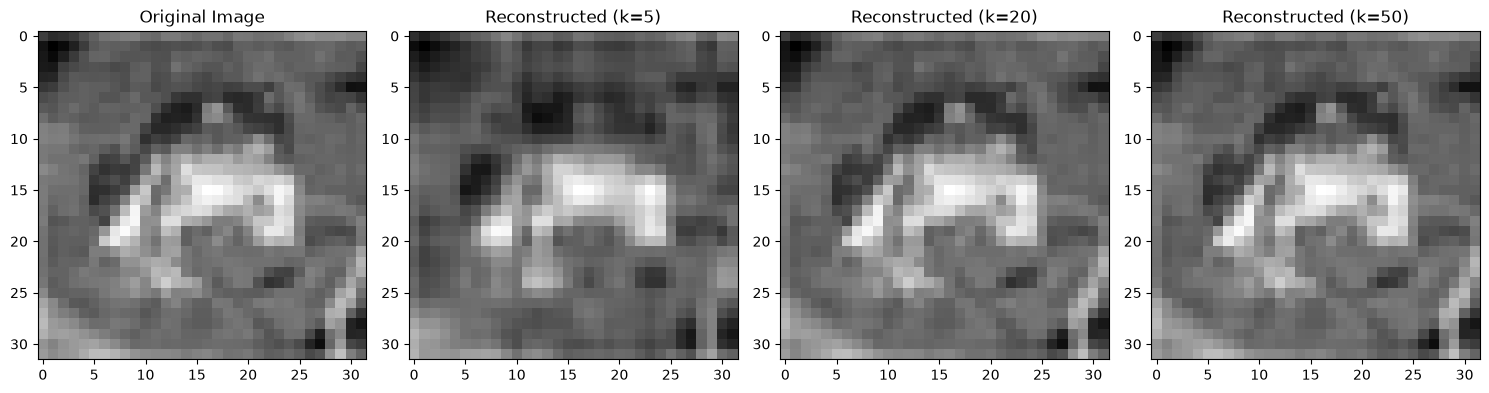

In [33]:
img = X[0].reshape(32, 32)
# M = U * S * Vt
U, S, Vt = np.linalg.svd(img, full_matrices=False)
def reconstruct(k):
    return (U[:, :k] * S[:k]) @ Vt[:k, :]
ks = [5, 20, 50]
fig, axes = plt.subplots(1, 4, figsize=(15, 5))
axes[0].imshow(image, cmap='gray')
axes[0].set_title("Original Image")

for i, k in enumerate(ks):
    img_rec = reconstruct(k)
    axes[i+1].imshow(img_rec, cmap='gray')
    axes[i+1].set_title(f"Reconstructed (k={k})")

plt.tight_layout()
plt.show()

### 3. Evaluation

To evaluate the effectiveness of SVD-based image compression, two quantitative metrics were used:

- **Reconstruction Error** ($||M-M_k||_F$): measures the difference between the original image $M$ and the reconstructed image $M_k$.
- **Compression Ratio**:

$$
\frac{k(m+n+1)}{m\times n}\times100\%
$$

which indicates the percentage of storage required relative to the original image.


#### 3.1 Experimental Results

In [34]:
m, n = 32, 32
total_pixels = m * n
data = []
for k in range(1, 33):
    M_k = reconstruct(k)
    err = np.linalg.norm(img - M_k, ord='fro')
    
    ratio = (k * (m + n + 1) / total_pixels) * 100
    
    data.append({'k': k, 'Error': round(err, 2), 'Compression Ratio (%)': round(ratio, 2)})

df = pd.DataFrame(data)

print(df.head(20))

     k    Error  Compression Ratio (%)
0    1  1016.15                   6.35
1    2   806.51                  12.70
2    3   661.24                  19.04
3    4   554.07                  25.39
4    5   468.24                  31.74
5    6   410.72                  38.09
6    7   355.43                  44.43
7    8   300.44                  50.78
8    9   251.11                  57.13
9   10   209.71                  63.48
10  11   177.48                  69.82
11  12   150.32                  76.17
12  13   127.42                  82.52
13  14   110.65                  88.87
14  15    94.55                  95.21
15  16    81.33                 101.56
16  17    70.39                 107.91
17  18    59.62                 114.26
18  19    51.50                 120.61
19  20    43.77                 126.95


#### 3.2 Reconstruction Error Curve

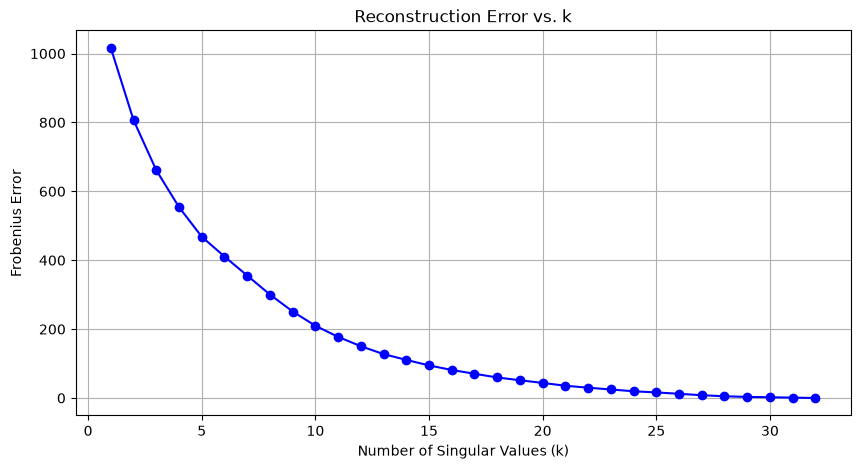

In [35]:
k_range = range(1, 33)
errors = []
ratios = []

for k in k_range:
    M_k = reconstruct(k)

    # Compute the Frobenius reconstruction error
    err = np.linalg.norm(img - M_k, ord='fro')
    errors.append(err)

    # Compute the compression ratio
    storage_ratio = (k * (m + n + 1)) / (m * n)
    ratios.append(storage_ratio)

plt.figure(figsize=(10, 5))
plt.plot(k_range, errors, marker='o', linestyle='-', color='b')
plt.title('Reconstruction Error vs. k')
plt.xlabel('Number of Singular Values (k)')
plt.ylabel('Frobenius Error')
plt.grid(True)
plt.show()

> **Observation:** The reconstruction error decreases rapidly for small values of $k$ and gradually levels off as $k$ increases.

### 4. Discussion

#### 4.1 Trade-off Between Quality and Compression

The results demonstrate a clear trade-off between image quality and storage efficiency:

- **$k < 10$:** High reconstruction error and noticeable loss of visual details, but excellent compression.
- **$k \approx 15$:** Provides a good balance between image quality and compression efficiency.
- **$k > 15$:** Further reduces reconstruction error, but the storage cost exceeds that of the original image.

> **Conclusion:** A value of approximately **$k = 15$** offers the best compromise between reconstruction quality and compression performance.

#### 4.2 Connection to AI

SVD is closely related to several important concepts in Artificial Intelligence:

##### Principal Component Analysis (PCA)

SVD forms the mathematical foundation of PCA. By retaining only the most important components, PCA reduces dimensionality while preserving the majority of the information.

##### Autoencoders

Autoencoders compress data into a lower-dimensional latent representation and then reconstruct it. This process is conceptually similar to selecting a small number of singular values in SVD.

##### Lossy Compression

SVD demonstrates that redundant information can be removed while maintaining the essential structure of the data. This principle is widely used in efficient AI systems and edge computing applications.
